In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("car_sales_new.csv")

# Data Discovery

In [3]:
df

,car,price,body,mileage,engV,engType,registration,year,model,drive
0,Ford,15500.0,crossover,68,2.5,Gas,yes,2010,Kuga,full
1,Mercedes-Benz,20500.0,sedan,173,1.8,Gas,yes,2011,E-Class,rear
2,Mercedes-Benz,35000.0,other,135,5.5,Petrol,yes,2008,CL 550,rear
3,Mercedes-Benz,17800.0,van,162,1.8,Diesel,yes,2012,B 180,front
4,Mercedes-Benz,33000.0,vagon,91,NaN,Other,yes,2013,E-Class,NaN
...,...,...,...,...,...,...,...,...,...,...
9571,Hyundai,14500.0,crossover,140,2.0,Gas,yes,2011,Tucson,front
9572,Volkswagen,2200.0,vagon,150,1.6,Petrol,yes,1986,Passat B2,front
9573,Mercedes-Benz,18500.0,crossover,180,3.5,Petrol,yes,2008,ML 350,full
9574,Lexus,16999.0,sedan,150,3.5,Gas,yes,2008,ES 350,front


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9576 entries, 0 to 9575
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   car           9576 non-null   str    
 1   price         9576 non-null   float64
 2   body          9576 non-null   str    
 3   mileage       9576 non-null   int64  
 4   engV          9142 non-null   float64
 5   engType       9576 non-null   str    
 6   registration  9576 non-null   str    
 7   year          9576 non-null   int64  
 8   model         9576 non-null   str    
 9   drive         9065 non-null   str    
dtypes: float64(2), int64(2), str(6)
memory usage: 748.3 KB


In [5]:
df.isnull().sum()

car               0
price             0
body              0
mileage           0
engV            434
engType           0
registration      0
year              0
model             0
drive           511
dtype: int64

In [6]:
((df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)).round(3) * 100

drive           5.3
engV            4.5
price           0.0
car             0.0
mileage         0.0
body            0.0
engType         0.0
registration    0.0
year            0.0
model           0.0
dtype: float64

In [7]:
df.describe()

,price,mileage,engV,year
count,9576.000000,9576.000000,9142.000000,9576.000000
mean,15633.317316,138.862364,2.646344,2006.605994
std,24106.523436,98.629754,5.927699,7.067924
min,0.000000,0.000000,0.100000,1953.000000
25%,4999.000000,70.000000,1.600000,2004.000000
50%,9200.000000,128.000000,2.000000,2008.000000
75%,16700.000000,194.000000,2.500000,2012.000000
max,547800.000000,999.000000,99.990000,2016.000000


In [8]:
print("Number of cars with a price equal to 0 (not logical):", len(df[df["price"] == 0]))

Number of cars with a price equal to 0 (not logical): 267


In [9]:
df.describe(exclude=["int", "float"])

,car,body,engType,registration,model,drive
count,9576,9576,9576,9576,9576,9065
unique,87,6,4,2,888,3
top,Volkswagen,sedan,Petrol,yes,E-Class,front
freq,936,3646,4379,9015,199,5188


## Car Sales Analysis

After exploring the dataset, I noticed that the data needs some cleaning before data analysis step.
### Data Cleaning Steps

- **Standardize column names**  
  Convert all column names to lowercase to avoid typing mistakes during data processing.

- **Clean the price column**  
  Remove extreme or unrealistic values such as **0**, because they do not represent real car values.

- **Handle missing values in engine volume (engV)**  
  Replace missing values using the **mean engine volume for each car model**.

- **Handle missing values in drive type (drive)**  
  Replace missing values with **"Unspecified"** since this column is categorical.

In [10]:
df.columns

Index(['car', 'price', 'body', 'mileage', 'engV', 'engType', 'registration',
       'year', 'model', 'drive'],
      dtype='str')

In [11]:
df.columns = ['car', 'price', 'body', 'mile_age', 'eng_volume', 'eng_type', 'registration','year', 'model', 'drive']

In [12]:
df.head()

,car,price,body,mile_age,eng_volume,eng_type,registration,year,model,drive
0,Ford,15500.0,crossover,68,2.5,Gas,yes,2010,Kuga,full
1,Mercedes-Benz,20500.0,sedan,173,1.8,Gas,yes,2011,E-Class,rear
2,Mercedes-Benz,35000.0,other,135,5.5,Petrol,yes,2008,CL 550,rear
3,Mercedes-Benz,17800.0,van,162,1.8,Diesel,yes,2012,B 180,front
4,Mercedes-Benz,33000.0,vagon,91,NaN,Other,yes,2013,E-Class,NaN


In [13]:
df["price"]= df["price"].replace(0, df["price"].mean())

In [14]:
df["eng_volume"] = df.groupby("model")["eng_volume"].transform(lambda x: x.fillna(x.mean()))

In [15]:
df["drive"] = df["drive"].fillna("UnSpecified")

In [16]:
df.columns

Index(['car', 'price', 'body', 'mile_age', 'eng_volume', 'eng_type',
       'registration', 'year', 'model', 'drive'],
      dtype='str')

In [17]:
mile_avg = df["mile_age"].mean()

In [18]:
mile_avg

np.float64(138.8623642439432)

In [19]:
df["mile_age_level"] = df["mile_age"].map(lambda miles:  "low mileage" if miles < mile_avg else "high mileage")

In [20]:
df[["mile_age","mile_age_level"]]

,mile_age,mile_age_level
0,68,low mileage
1,173,high mileage
2,135,low mileage
3,162,high mileage
4,91,low mileage
...,...,...
9571,140,high mileage
9572,150,high mileage
9573,180,high mileage
9574,150,high mileage


# Data Visualisation

In [21]:
df["year"] = df["year"].astype(str)

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9576 entries, 0 to 9575
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   car             9576 non-null   str    
 1   price           9576 non-null   float64
 2   body            9576 non-null   str    
 3   mile_age        9576 non-null   int64  
 4   eng_volume      9545 non-null   float64
 5   eng_type        9576 non-null   str    
 6   registration    9576 non-null   str    
 7   year            9576 non-null   str    
 8   model           9576 non-null   str    
 9   drive           9576 non-null   str    
 10  mile_age_level  9576 non-null   str    
dtypes: float64(2), int64(1), str(8)
memory usage: 823.1 KB


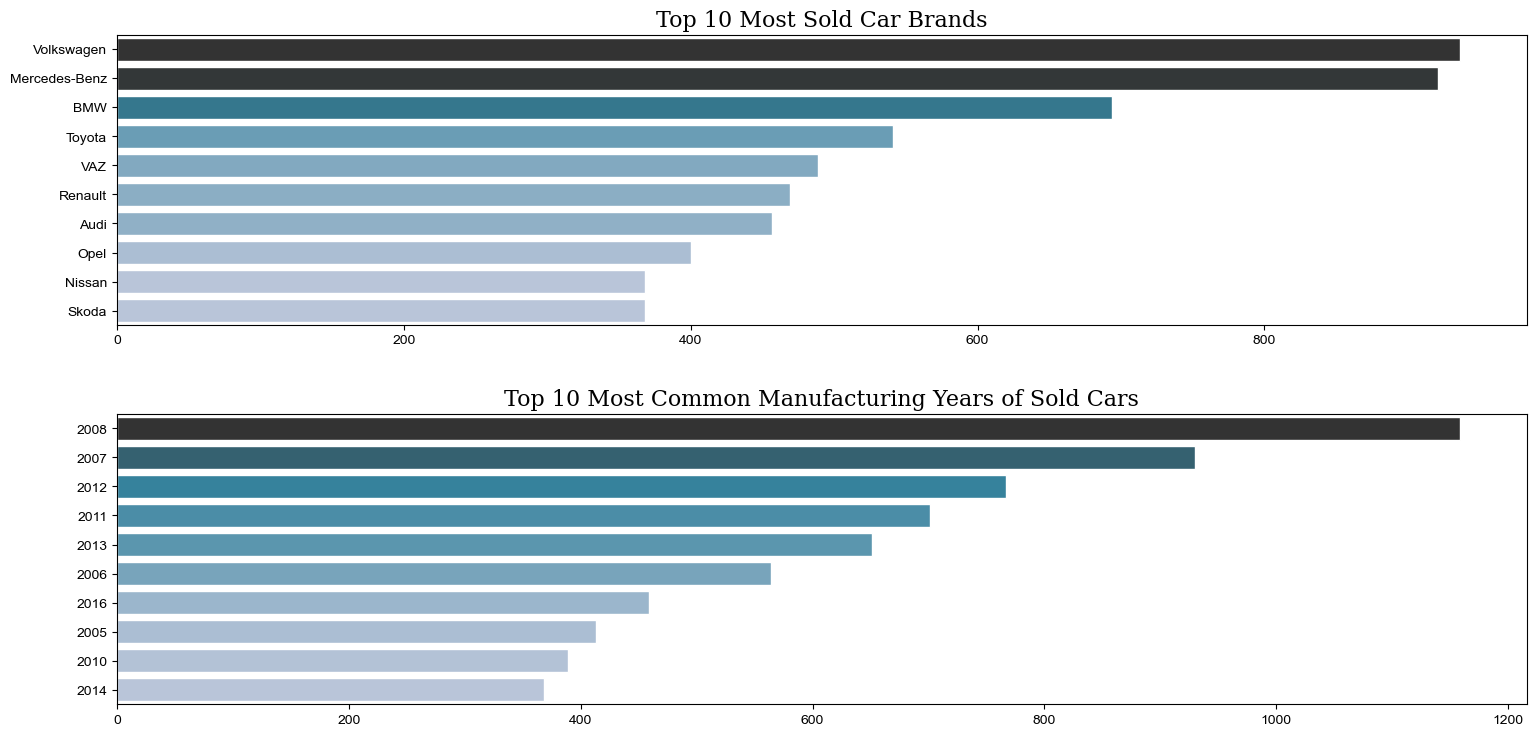

In [23]:
columns=["car", "year"]

fig, ax = plt.subplots(2, 1, figsize=(16, 8))
sns.set_style("ticks")
for i, col in enumerate(columns):
    df_plot = df[col].value_counts().reset_index().head(10)
    sns.barplot(data=df_plot, y=col, x="count", ax=ax[i], hue="count", palette="PuBuGn_d")
    ax[i].set_xlabel("")
    ax[i].set_ylabel("")
    ax[i].legend().set_visible(False)

ax[0].set_title("Top 10 Most Sold Car Brands", fontsize=16, fontfamily="serif")
ax[1].set_title("Top 10 Most Common Manufacturing Years of Sold Cars",fontsize=16, fontfamily="serif")
fig.tight_layout(pad=3)
plt.show()

In [24]:
df.columns

Index(['car', 'price', 'body', 'mile_age', 'eng_volume', 'eng_type',
       'registration', 'year', 'model', 'drive', 'mile_age_level'],
      dtype='str')

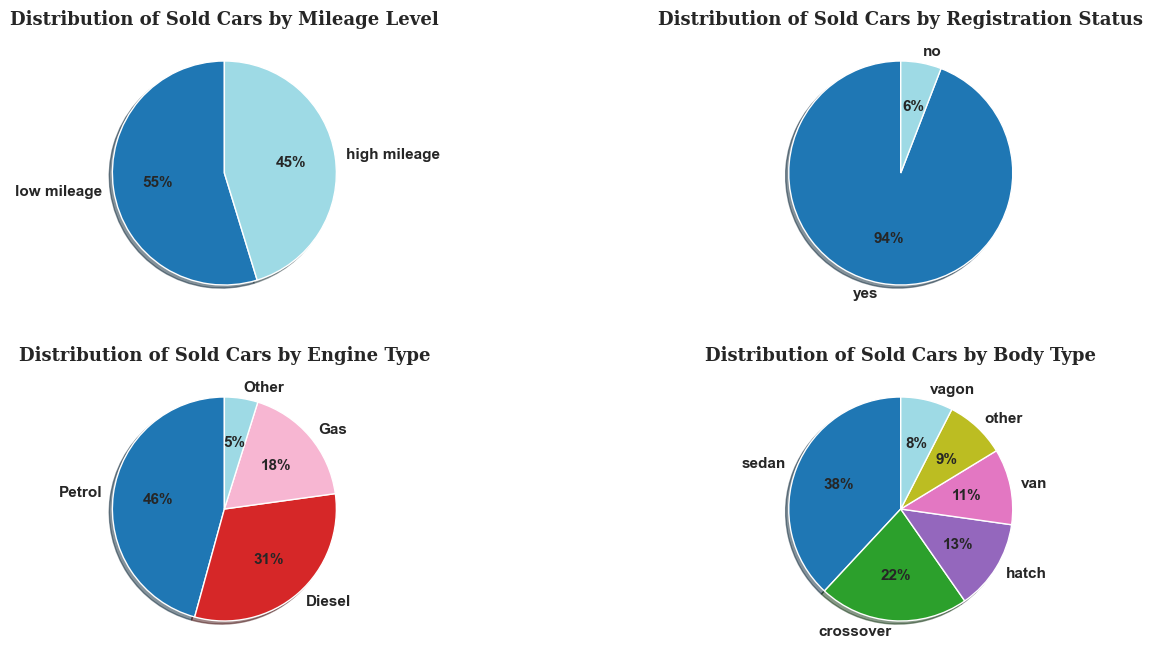

In [25]:
titles = {
    "mile_age_level": "Distribution of Sold Cars by Mileage Level",
    "registration": "Distribution of Sold Cars by Registration Status",
    "eng_type": "Distribution of Sold Cars by Engine Type",
    "body": "Distribution of Sold Cars by Body Type"
}

fig, ax = plt.subplots(2, 2, figsize=(16, 8))


for index, (col, title) in enumerate(titles.items()):
    axis = ax[index//2, index%2]

    df_plot = df[col].value_counts()
    df_plot.plot(
    kind="pie",
    ax=axis,
    startangle=90,
    autopct="%0.f%%",
    shadow=True,
    colormap="tab20" ,
    textprops={"weight": "bold", "fontsize": 11}
)

    axis.set_title(title, fontsize=13, fontfamily="serif",fontweight="bold")
    axis.set_ylabel("")
    axis.set_xlabel("")

In [26]:
df.columns

Index(['car', 'price', 'body', 'mile_age', 'eng_volume', 'eng_type',
       'registration', 'year', 'model', 'drive', 'mile_age_level'],
      dtype='str')

# Identify the top three models for each of the top three most sold car brands.

In [27]:
df["car"].value_counts().head(3).index.to_list()

['Volkswagen', 'Mercedes-Benz', 'BMW']

In [28]:
top_brands = df["car"].value_counts().head(4).index.to_list()

In [29]:
top_brands

['Volkswagen', 'Mercedes-Benz', 'BMW', 'Toyota']

In [30]:
df.columns

Index(['car', 'price', 'body', 'mile_age', 'eng_volume', 'eng_type',
       'registration', 'year', 'model', 'drive', 'mile_age_level'],
      dtype='str')

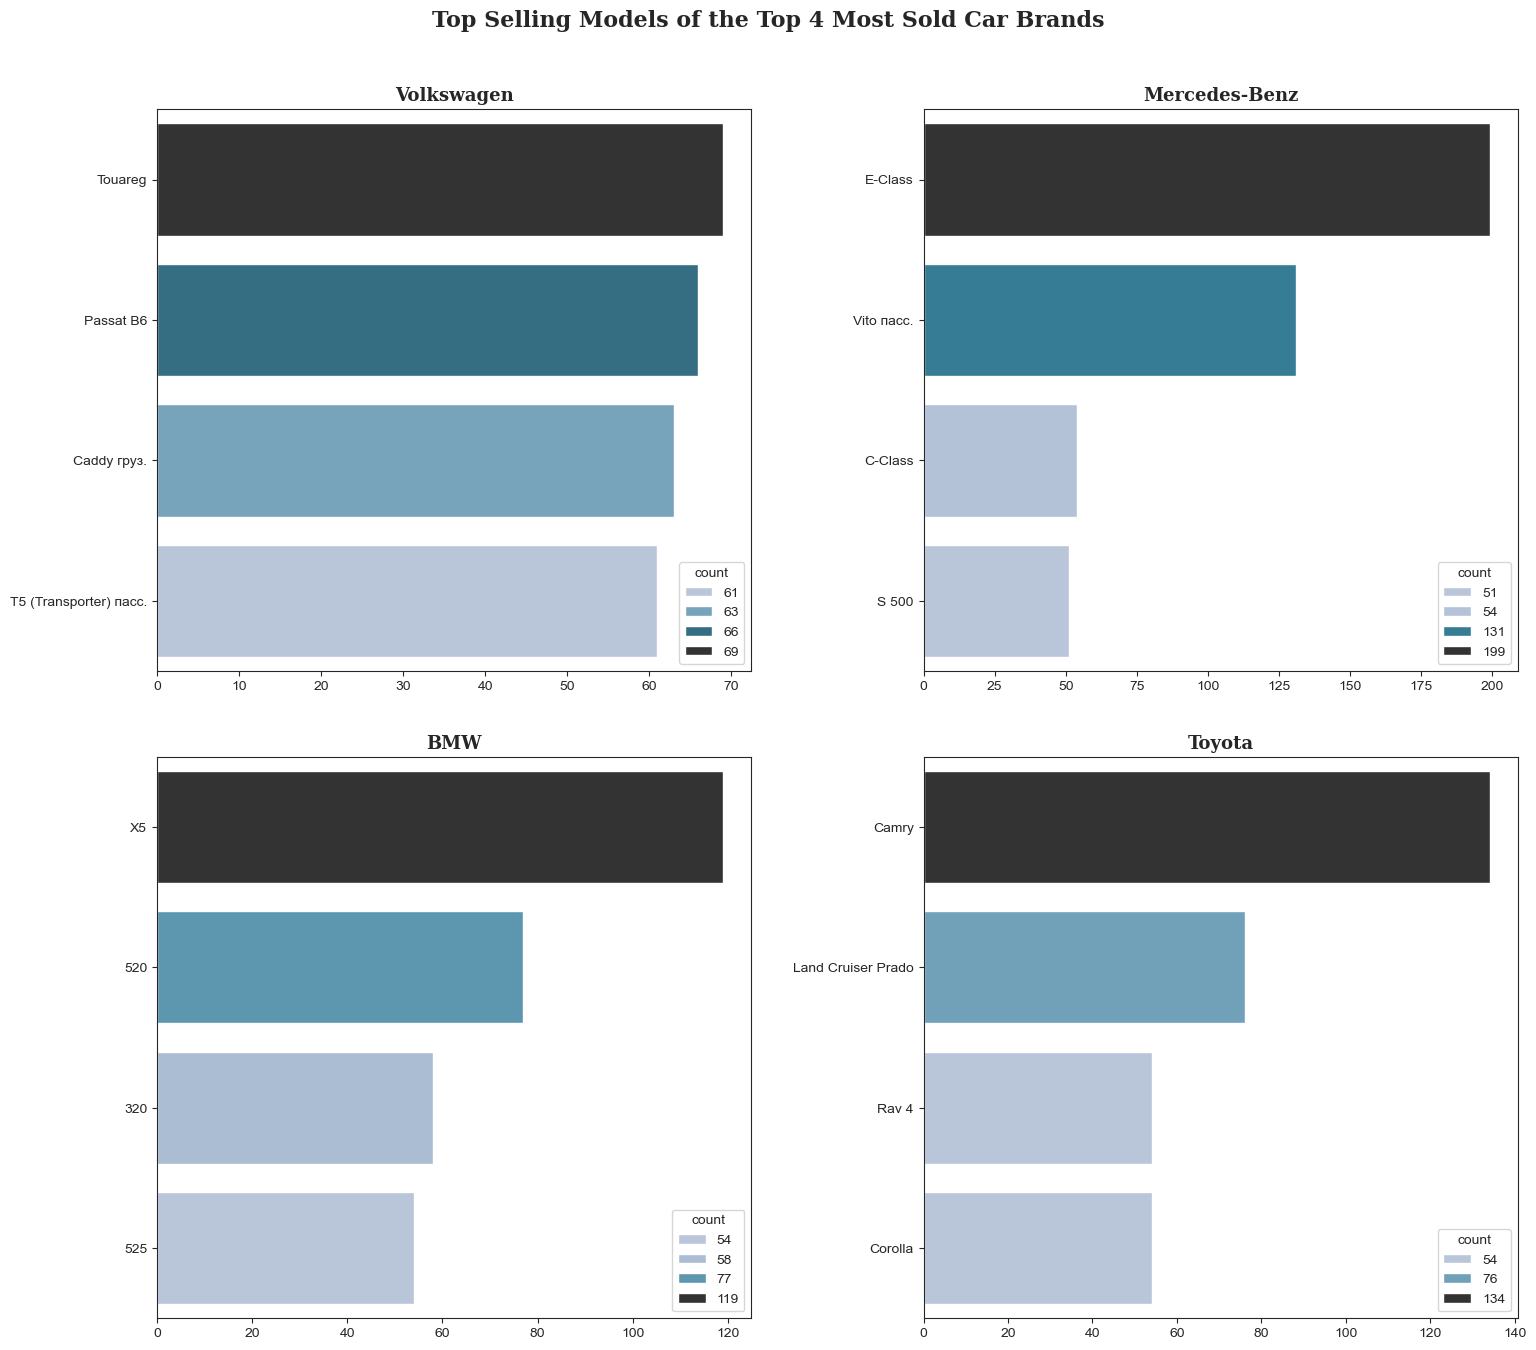

In [31]:
fig, ax = plt.subplots(2,2, figsize=(16,14))

for i, brand in enumerate(top_brands):
    axis= ax[i//2, i%2]
    df_filtered=df.loc[df["car"] == brand].copy()
    df_plot = df_filtered["model"].value_counts().head(4).reset_index()
    sns.barplot(x="count", y="model", data=df_plot, hue="count", palette="PuBuGn_d", ax=axis )
    axis.set_title(brand, fontsize=13, fontfamily="serif",fontweight="bold")
    axis.set_ylabel("")
    axis.set_xlabel("")
fig.suptitle("Top Selling Models of the Top 4 Most Sold Car Brands", fontsize=16, fontfamily="serif",fontweight="bold")
fig.tight_layout(pad =3)

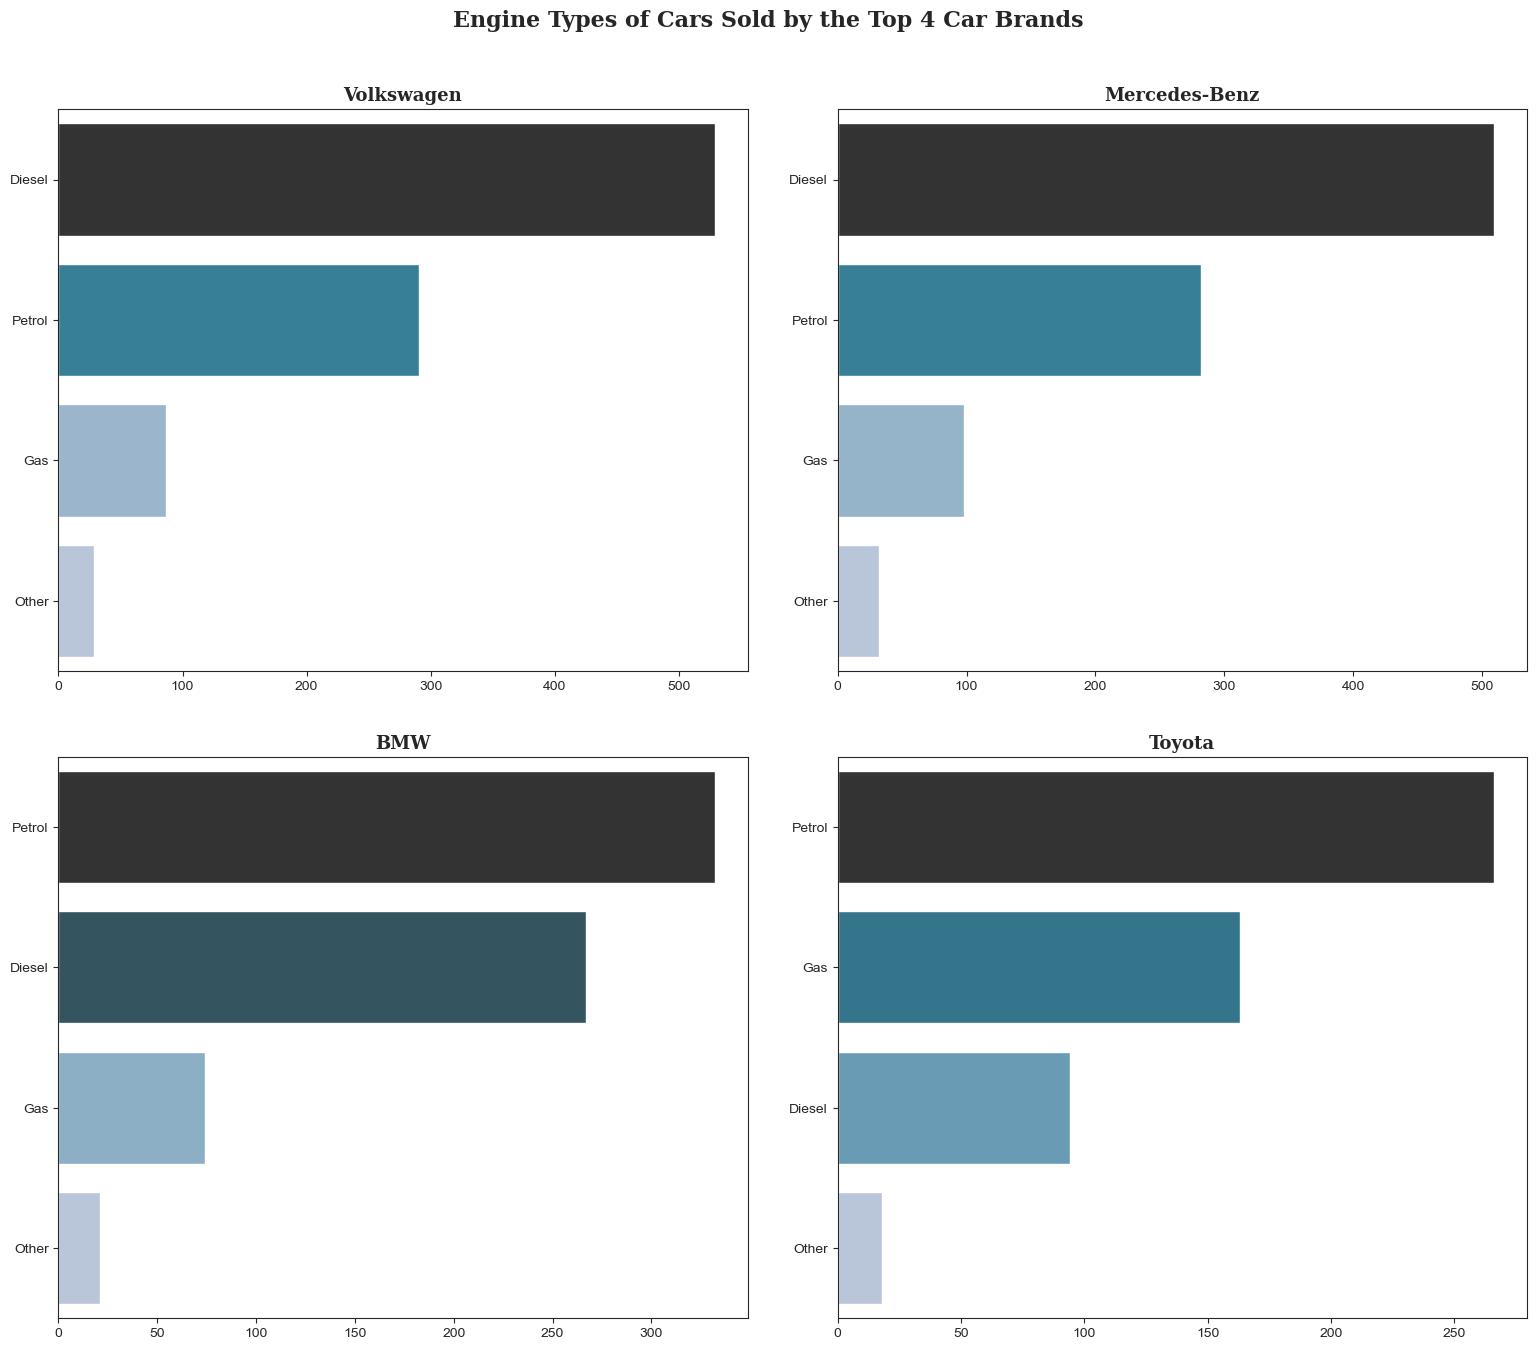

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(16,14))

for i, brand in enumerate(top_brands):
    axis= ax[i//2, i%2]
    df_filtered=df.loc[df["car"] == brand].copy()
    df_plot = df_filtered["eng_type"].value_counts().reset_index()
    sns.barplot(x="count", y="eng_type", data=df_plot, hue="count", palette="PuBuGn_d", ax=axis, legend=False, )
    axis.set_title(brand, fontsize=13, fontfamily="serif",fontweight="bold")
    axis.set_ylabel("")
    axis.set_xlabel("")
fig.suptitle("Engine Types of Cars Sold by the Top 4 Car Brands", fontsize=16, fontfamily="serif",fontweight="bold")
fig.tight_layout(pad =3)

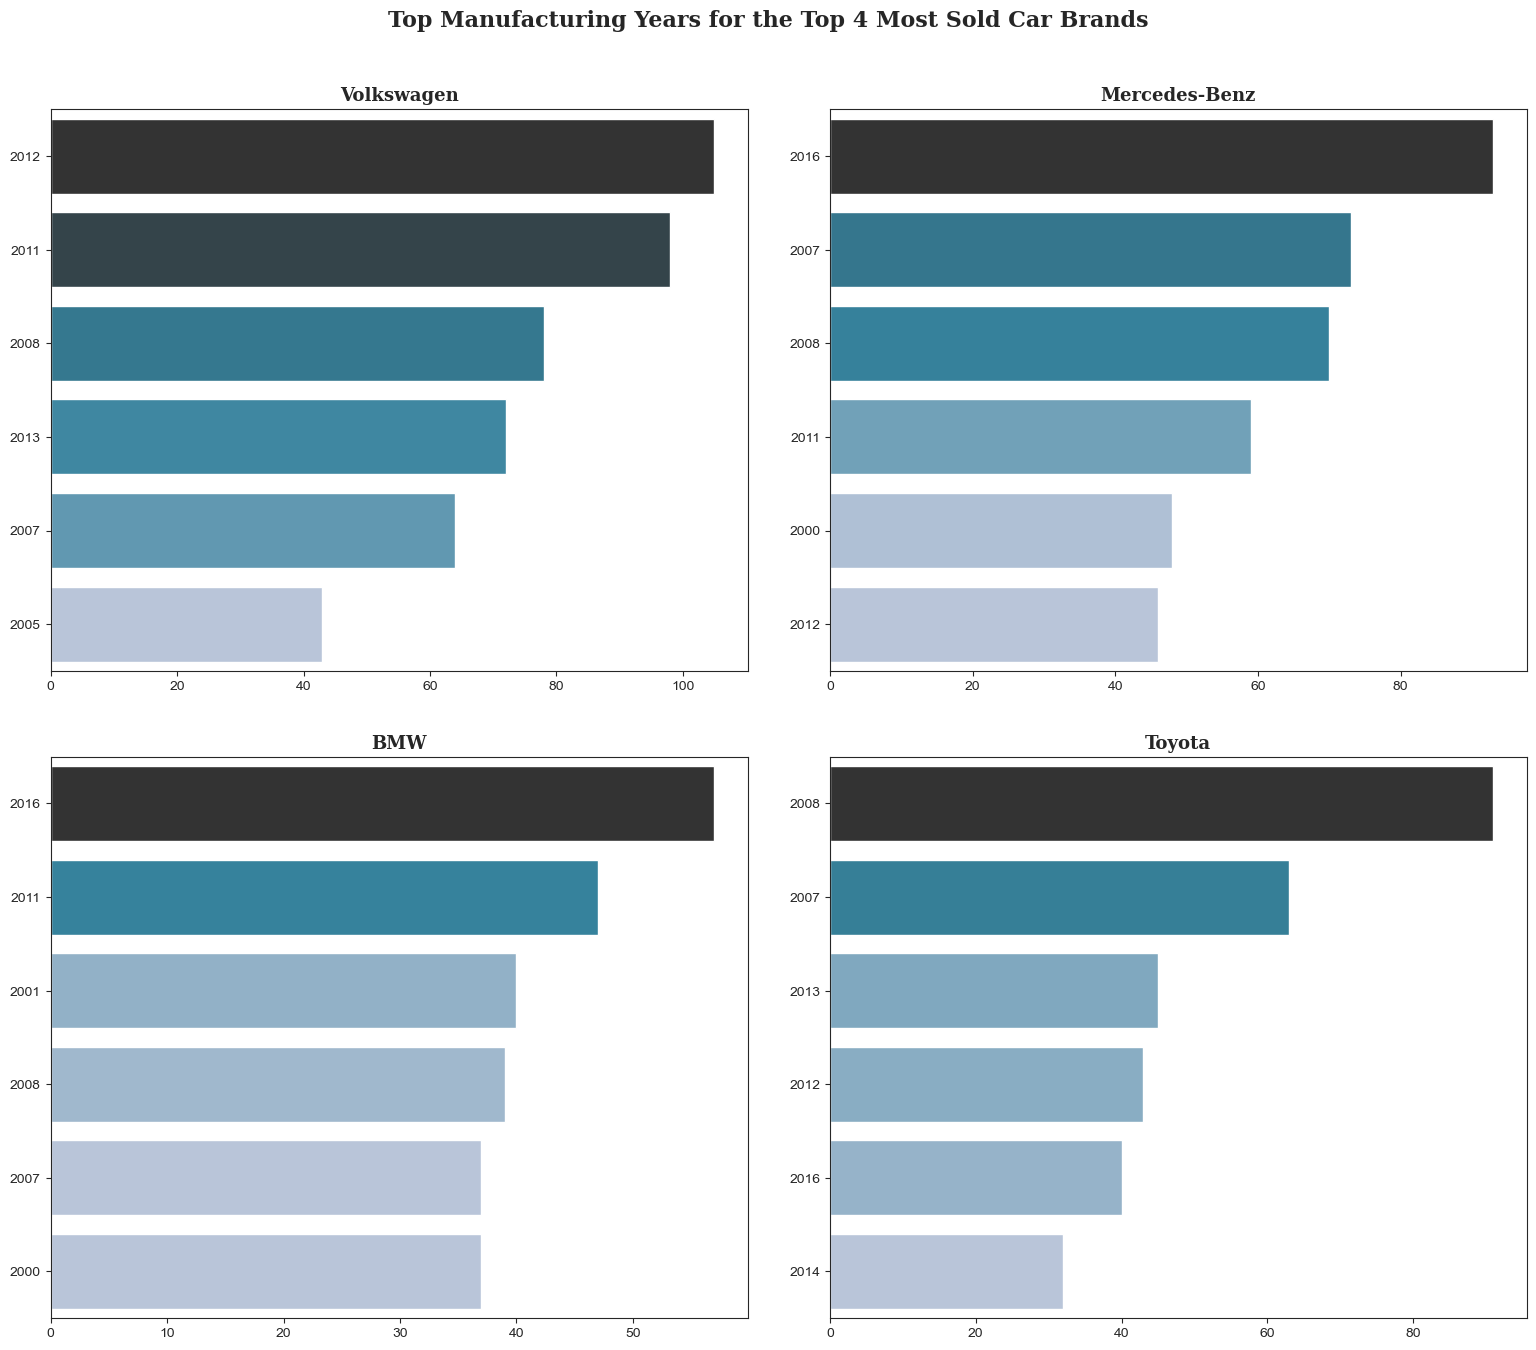

In [32]:
fig, ax = plt.subplots(2,2, figsize=(16,14))

for i, brand in enumerate(top_brands):
    axis= ax[i//2, i%2]
    df_filtered=df.loc[df["car"] == brand].copy()
    df_plot = df_filtered["year"].value_counts().head(6).reset_index()
    sns.barplot(x="count", y="year", data=df_plot, hue="count", palette="PuBuGn_d", ax=axis, legend=False, )
    axis.set_title(brand, fontsize=13, fontfamily="serif",fontweight="bold")
    axis.set_ylabel("")
    axis.set_xlabel("")
fig.suptitle("Top Manufacturing Years for the Top 4 Most Sold Car Brands", fontsize=16, fontfamily="serif",fontweight="bold")
fig.tight_layout(pad =3)

df.columns

In [33]:
df.columns

Index(['car', 'price', 'body', 'mile_age', 'eng_volume', 'eng_type',
       'registration', 'year', 'model', 'drive', 'mile_age_level'],
      dtype='str')

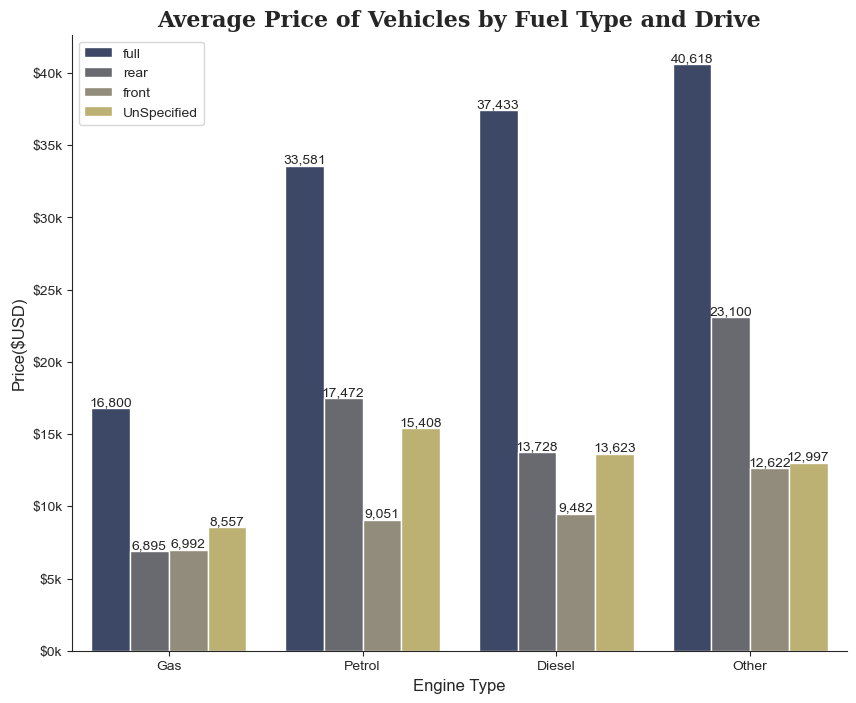

In [35]:
plt.figure(figsize=(10,8))
axis = sns.barplot(x="eng_type",y="price",data=df, hue="drive", palette="cividis", errorbar=None)
sns.despine()

for container in axis.containers:
    for bar in container:
        value = bar.get_height()

        axis.text(
            bar.get_x() + bar.get_width()/2,
            value,
            f"{value:,.0f}",
            ha="center",
            va="bottom"
        )
axis.yaxis.set_major_formatter(plt.FuncFormatter(lambda price,_: f"${int(price/1000)}k" ))

axis.set_ylabel("Price($USD)",fontsize=12)
axis.set_xlabel("Engine Type", fontsize=12)
axis.set_title("Average Price of Vehicles by Fuel Type and Drive", fontsize=16, fontfamily="serif",fontweight="bold")

plt.legend(loc="upper left")

In [36]:
top_10_brands = df["car"].value_counts().head(10).index.tolist()

In [37]:
top_10_brands

['Volkswagen',
 'Mercedes-Benz',
 'BMW',
 'Toyota',
 'VAZ',
 'Renault',
 'Audi',
 'Opel',
 'Nissan',
 'Skoda']

In [38]:
df_plot= df[df["car"].isin(top_10_brands)]

In [39]:
df.columns

Index(['car', 'price', 'body', 'mile_age', 'eng_volume', 'eng_type',
       'registration', 'year', 'model', 'drive', 'mile_age_level'],
      dtype='str')

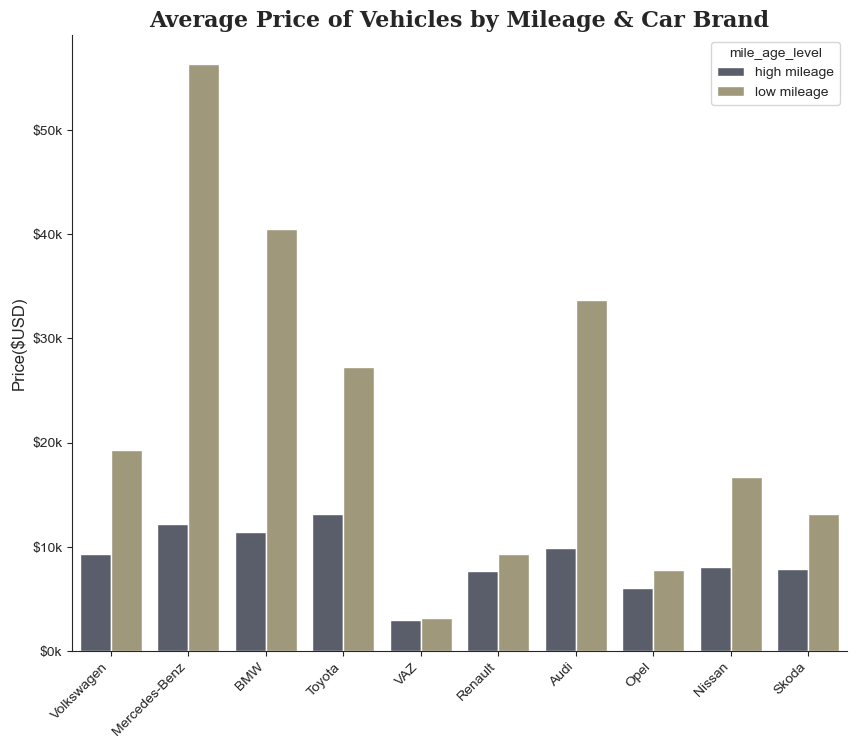

In [40]:
plt.figure(figsize=(10,8))
axis = sns.barplot(x="car",y="price",data=df_plot,hue="mile_age_level",palette="cividis" ,errorbar=None, order=top_10_brands)
sns.despine()

axis.yaxis.set_major_formatter(plt.FuncFormatter(lambda price,_: f"${int(price/1000)}k" ))
plt.xticks(ha="right", rotation=45)

axis.set_ylabel("Price($USD)",fontsize=12)
axis.set_xlabel("")
axis.set_title("Average Price of Vehicles by Mileage & Car Brand", fontsize=16, fontfamily="serif",fontweight="bold")


plt.show()

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9576 entries, 0 to 9575
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   car             9576 non-null   str    
 1   price           9576 non-null   float64
 2   body            9576 non-null   str    
 3   mile_age        9576 non-null   int64  
 4   eng_volume      9545 non-null   float64
 5   eng_type        9576 non-null   str    
 6   registration    9576 non-null   str    
 7   year            9576 non-null   int64  
 8   model           9576 non-null   str    
 9   drive           9576 non-null   str    
 10  mile_age_level  9576 non-null   str    
dtypes: float64(2), int64(2), str(7)
memory usage: 823.1 KB


In [41]:
df["year"] = df["year"].astype(int)

In [47]:
df.dtypes

car                   str
price             float64
body                  str
mile_age            int64
eng_volume        float64
eng_type              str
registration          str
year                int64
model                 str
drive                 str
mile_age_level        str
dtype: object

In [48]:
corr = df.loc[:,df.dtypes != "str"].corr("pearson")
corr

,price,mile_age,eng_volume,year
price,1.000000,-0.323532,0.048127,0.380048
mile_age,-0.323532,1.000000,0.044350,-0.495599
eng_volume,0.048127,0.044350,1.000000,-0.045365
year,0.380048,-0.495599,-0.045365,1.000000


[Text(0, 0.5, 'Year'),
 Text(0, 1.5, 'Engine Volume'),
 Text(0, 2.5, 'Mileage'),
 Text(0, 3.5, 'Price')]

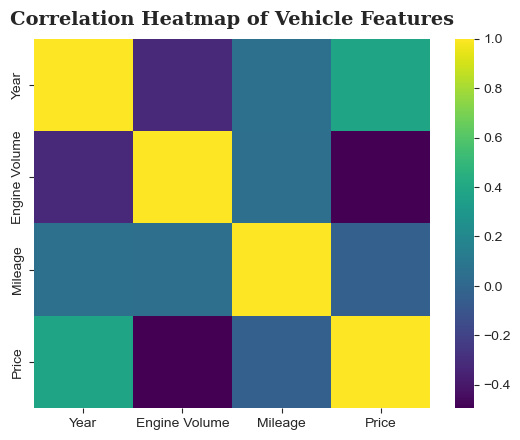

In [49]:
ax = sns.heatmap(corr, cmap="viridis")
plt.title("Correlation Heatmap of Vehicle Features", pad=10,  fontsize=14, fontfamily="serif",fontweight="bold")
ax.set_xticklabels(["Year","Engine Volume","Mileage","Price"])
ax.set_yticklabels(["Year","Engine Volume","Mileage","Price"])

In [52]:
df["body"].unique()

<StringArray>
['crossover', 'sedan', 'other', 'van', 'vagon', 'hatch']
Length: 6, dtype: str